Name: Boga Petruska\
Class: ECBS5245 - Data Analysis 4: Causal Analysis (advanced)\
Assignment 2: Panel Data Exercise\
Date: March 26, 2026

# CO2 emission and GDP

- To what extent does economic activity cause CO2 emission?
- Importance
    - CO2 emission may be the most important channel through which human activity leads to climate change
- Two flow variables
    - GDP: produced goods and services in a country over a year
    - CO2: produced CO2 in a country over a year

## CO2 emission and GDP Data
- World Development Indicators
    - Time series by country, 1992 to last available year
- GDP per capita
    - Measured in PPP USD at constant prices
- CO2 emission per capita
    - Get total emission and divide by population

### Data Source
- Source: World Bank DataBank, World Development Indicators
- Countries: All available
- Time range: 1992 onward
- Download date: 2026-03-19
- Series used:
    - `NY.GDP.PCAP.PP.KD`: GDP per capita, PPP (constant 2021 international $)
    - `SP.POP.TOTL`: Population, total (persons)
    - `EN.GHG.CO2.MT.CE.AR5`: CO2 emissions (total) excluding LULUCF (Mt CO2e)

*Note: LULUCF = Land Use, Land-Use Change and Forestry. Excluding LULUCF means only emissions from fossil fuels and industrial processes are counted, not carbon fluxes from deforestation or reforestation.*

### Citation
World Bank. (2026). World Development Indicators. Retrieved March 19, 2026, from https://databank.worldbank.org/source/world-development-indicators

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from stargazer.stargazer import Stargazer
import pycountry
import wbgapi as wb
import warnings
import os
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
np.random.seed(42)

# Global plot style
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind", font_scale=1.1)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "figure.dpi": 120,
})

def _latex_escape(s):
    """Escape LaTeX special characters in a string."""
    for ch, repl in [("%", r"\%"), ("$", r"\$"), ("_", r"\_"), ("&", r"\&"), ("#", r"\#")]:
        s = s.replace(ch, repl)
    return s

class DualTable:
    """Renders as HTML in notebook, LaTeX in PDF export."""
    def __init__(self, df, caption=None):
        self.df = df
        self.caption = caption

    def _repr_html_(self):
        html = ""
        if self.caption:
            html += f"<b>{self.caption}</b><br>"
        html += self.df.to_html()
        return html

    def _repr_latex_(self):
        df_safe = self.df.copy()
        df_safe.columns = [_latex_escape(str(c)) for c in df_safe.columns]
        if df_safe.index.dtype == object:
            df_safe.index = pd.Index([_latex_escape(str(v)) for v in df_safe.index])
        if df_safe.index.name:
            df_safe.index.name = _latex_escape(str(df_safe.index.name))
        for col in df_safe.columns:
            if df_safe[col].dtype == object:
                df_safe[col] = df_safe[col].apply(lambda x: _latex_escape(str(x)))
        ncols = len(df_safe.columns)
        return df_safe.to_latex(
            caption=self.caption,
            position="h",
            column_format="l" + "r" * ncols,
            escape=False,
        )

## Load and reshape data

In [2]:
# Load raw World Bank data (wide format, skip footer rows)
raw = pd.read_csv(
    "data/c7a77ee3-11bf-46d0-91bd-3695640f0d89_Data.csv",
    na_values="..",
)

# Drop footer rows (no Country Code)
raw = raw.dropna(subset=["Country Code"])

# Keep only the three series we need (compute CO2 per capita manually)
series_keep = ["NY.GDP.PCAP.PP.KD", "SP.POP.TOTL", "EN.GHG.CO2.MT.CE.AR5"]
raw = raw[raw["Series Code"].isin(series_keep)].copy()

# Identify year columns
year_cols = [c for c in raw.columns if c.endswith("]") and "YR" in c]

# Melt to long format: one row per country-series-year
long = raw.melt(
    id_vars=["Country Name", "Country Code", "Series Code"],
    value_vars=year_cols,
    var_name="year_raw",
    value_name="value",
)

# Extract numeric year
long["year"] = long["year_raw"].str.extract(r"(\d{4})").astype(int)
long = long.drop(columns=["year_raw"])

# Pivot so each series becomes its own column
panel = long.pivot_table(
    index=["Country Name", "Country Code", "year"],
    columns="Series Code",
    values="value",
).reset_index()

# Rename columns
panel.columns.name = None
panel = panel.rename(columns={
    "Country Name": "country",
    "Country Code": "iso3",
    "NY.GDP.PCAP.PP.KD": "gdp_pc",
    "SP.POP.TOTL": "population",
    "EN.GHG.CO2.MT.CE.AR5": "co2_total_mt",
})

# Compute CO2 per capita (Mt to tonnes: multiply by 1e6, then divide by population)
panel["co2_pc"] = (panel["co2_total_mt"] * 1e6) / panel["population"]

print(f"Panel: {panel.shape[0]} obs, {panel['iso3'].nunique()} countries, {panel['year'].min()}-{panel['year'].max()}")
DualTable(panel.head(10), caption="Panel data preview (first 10 rows)")

Panel: 8745 obs, 265 countries, 1992-2024


,country,iso3,year,co2_total_mt,gdp_pc,population,co2_pc
0,Afghanistan,AFG,1992,1.8107,NaN,13278974.0,0.136358
1,Afghanistan,AFG,1993,1.7729,NaN,14943172.0,0.118643
2,Afghanistan,AFG,1994,1.6737,NaN,16250794.0,0.102992
3,Afghanistan,AFG,1995,1.4526,NaN,17065836.0,0.085117
4,Afghanistan,AFG,1996,1.4056,NaN,17763266.0,0.079130
5,Afghanistan,AFG,1997,1.3735,NaN,18452091.0,0.074436
6,Afghanistan,AFG,1998,1.4093,NaN,19159996.0,0.073554
7,Afghanistan,AFG,1999,1.3633,NaN,19887785.0,0.068550
8,Afghanistan,AFG,2000,1.0093,1617.826475,20130327.0,0.050138
9,Afghanistan,AFG,2001,0.9402,1454.110782,20284307.0,0.046351


In [ ]:
# Investigate extreme CO2 per capita values
top_co2 = panel.nlargest(10, "co2_pc")[["country", "iso3", "year", "co2_total_mt", "population", "co2_pc"]].copy()
top_co2["co2_pc"] = top_co2["co2_pc"].round(1)
top_co2["population"] = top_co2["population"].astype(int)
print("Top 10 CO2 per capita observations:")
print(top_co2.to_string(index=False))

# Palau has implausible values (>80 t/capita; world max is ~35 for Qatar)
# Likely international shipping/aviation emissions misattributed to it
outlier_threshold = 50  # t CO2 per capita
countries_outlier = panel.loc[panel["co2_pc"] > outlier_threshold, "iso3"].unique()
print(f"\nExcluding {', '.join(countries_outlier)} due to implausible emission values.")
panel = panel[~panel["iso3"].isin(countries_outlier)].copy()
print(f"Panel after exclusion: {panel['iso3'].nunique()} countries, max CO2/capita: {panel['co2_pc'].max():.1f} t")

Top 10 CO2 per capita observations:
country iso3  year  co2_total_mt  population  co2_pc
  Palau  PLW  2012        3.6039       17765   202.9
  Palau  PLW  1994        2.9958       16770   178.6
  Palau  PLW  1997        2.5182       18108   139.1
  Palau  PLW  1995        2.3497       17195   136.7
  Palau  PLW  2011        2.3697       18078   131.1
  Palau  PLW  1999        2.4199       18901   128.0
  Palau  PLW  1996        2.2116       17654   125.3
  Palau  PLW  1998        2.2788       18524   123.0
  Palau  PLW  1992        1.9558       15989   122.3
  Palau  PLW  1993        2.0017       16372   122.3

Excluding PLW, QAT due to implausible emission values.
Panel after exclusion: 263 countries, max CO2/capita: 34.5 t


In [4]:
# Descriptive statistics for key variables
desc = panel[["gdp_pc", "co2_total_mt", "co2_pc"]].describe()
desc.columns = ["GDP per capita (PPP)", "CO2 total (Mt)", "CO2 per capita (t)"]

# Format: commas for GDP, 3 decimals for CO2
desc["GDP per capita (PPP)"] = desc["GDP per capita (PPP)"].map(lambda x: f"{x:,.1f}")
desc["CO2 total (Mt)"] = desc["CO2 total (Mt)"].map(lambda x: f"{x:,.3f}")
desc["CO2 per capita (t)"] = desc["CO2 per capita (t)"].map(lambda x: f"{x:,.3f}")

DualTable(desc, caption="Descriptive statistics")

,GDP per capita (PPP),CO2 total (Mt),CO2 per capita (t)
count,"7,933.0","8,217.000","8,217.000"
mean,"20,525.5","1,091.356",4.118
std,"22,350.2","3,689.076",5.050
min,510.8,0.000,0.000
25%,"4,631.8",2.088,0.602
50%,"12,040.1",21.019,2.341
75%,"29,346.4",246.414,5.926
max,"174,569.5","39,632.664",34.529


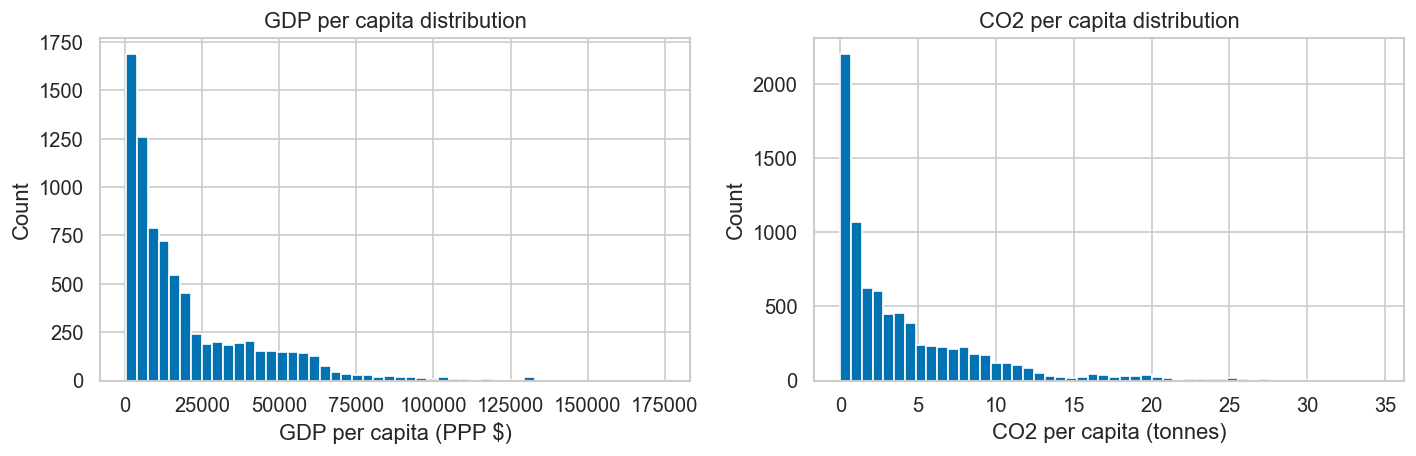

In [5]:
# Distribution of key variables
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(panel["gdp_pc"].dropna(), bins=50, edgecolor="white")
axes[0].set(xlabel="GDP per capita (PPP $)", ylabel="Count", title="GDP per capita distribution")

axes[1].hist(panel["co2_pc"].dropna(), bins=50, edgecolor="white")
axes[1].set(xlabel="CO2 per capita (tonnes)", ylabel="Count", title="CO2 per capita distribution")

plt.tight_layout()
plt.show()

# Add income group classification from World Bank API
income_map = {}
for eco in wb.economy.list():
    if not eco["aggregate"] and eco["incomeLevel"]:
        income_map[eco["id"]] = eco["incomeLevel"]

income_labels = {"HIC": "High income", "UMC": "Upper middle", "LMC": "Lower middle", "LIC": "Low income"}
panel["income_group"] = panel["iso3"].map(income_map).map(income_labels)

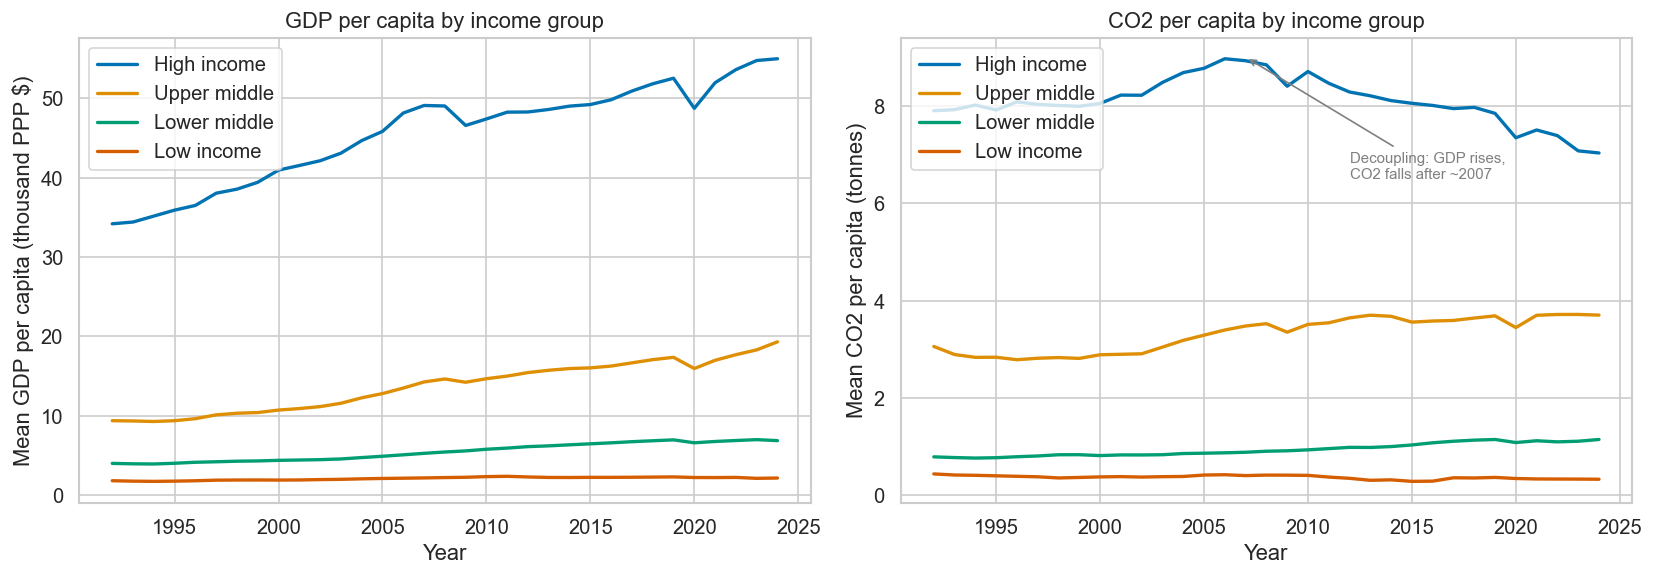

In [6]:
# Time trends by income group
grouped = panel.groupby(["year", "income_group"])[["gdp_pc", "co2_pc"]].mean().reset_index()
order = ["High income", "Upper middle", "Lower middle", "Low income"]
colors = dict(zip(order, sns.color_palette("colorblind", 4)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for grp in order:
    sub = grouped[grouped["income_group"] == grp]
    axes[0].plot(sub["year"], sub["gdp_pc"] / 1000, label=grp, color=colors[grp], linewidth=2)
    axes[1].plot(sub["year"], sub["co2_pc"], label=grp, color=colors[grp], linewidth=2)

axes[0].set(xlabel="Year", ylabel="Mean GDP per capita (thousand PPP $)",
            title="GDP per capita by income group")
axes[0].legend(loc="upper left")

axes[1].set(xlabel="Year", ylabel="Mean CO2 per capita (tonnes)",
            title="CO2 per capita by income group")
axes[1].legend(loc="upper left")

# Annotate the decoupling
axes[1].annotate("Decoupling: GDP rises,\nCO2 falls after ~2007",
                 xy=(2007, 9.0), xytext=(2012, 6.5),
                 arrowprops=dict(arrowstyle="->", color="gray"),
                 fontsize=9, color="gray")

plt.tight_layout()
plt.show()

In [7]:
# Coverage summary
n_countries = panel["iso3"].nunique()
yr_min, yr_max = panel["year"].min(), panel["year"].max()

summary = pd.DataFrame({
    "Variable": ["GDP per capita", "CO2 total", "Population", "CO2 per capita (computed)"],
    "Non-missing": [
        f"{panel['gdp_pc'].notna().sum():,}",
        f"{panel['co2_total_mt'].notna().sum():,}",
        f"{panel['population'].notna().sum():,}",
        f"{panel['co2_pc'].notna().sum():,}",
    ],
    "Missing": [
        f"{panel['gdp_pc'].isna().sum():,}",
        f"{panel['co2_total_mt'].isna().sum():,}",
        f"{panel['population'].isna().sum():,}",
        f"{panel['co2_pc'].isna().sum():,}",
    ],
    "Missing %": [
        f"{panel['gdp_pc'].isna().mean():.1%}",
        f"{panel['co2_total_mt'].isna().mean():.1%}",
        f"{panel['population'].isna().mean():.1%}",
        f"{panel['co2_pc'].isna().mean():.1%}",
    ],
}).set_index("Variable")

DualTable(summary, caption=f"Data availability ({n_countries} countries/territories, {yr_min}--{yr_max})")

,Non-missing,Missing,Missing %
Variable,,,
GDP per capita,"7,933",746,8.6%
CO2 total,"8,217",462,5.3%
Population,"8,679",0,0.0%
CO2 per capita (computed),"8,217",462,5.3%


## Coverage and sample selection

In [8]:
# The World Bank dataset includes aggregates (e.g. "World", "Euro area", "Low income")
# alongside real countries. We keep only entities with valid ISO 3166-1 alpha-3 codes,
# which are exactly 3 letters and correspond to actual countries/territories.



# Get the set of valid ISO 3166-1 alpha-3 codes
valid_iso3 = {c.alpha_3 for c in pycountry.countries}

# Flag which codes in our panel are real countries
panel["is_country"] = panel["iso3"].isin(valid_iso3)

n_before = panel["iso3"].nunique()
dropped = panel[~panel["is_country"]]["iso3"].unique()
n_dropped = len(dropped)

print(f"Entities in raw data: {n_before}")
print(f"Non-country aggregates dropped ({n_dropped}):")
for code in sorted(dropped):
    name = panel.loc[panel["iso3"] == code, "country"].iloc[0]
    print(f"  {code}: {name}")

# Keep only real countries
panel = panel[panel["is_country"]].drop(columns=["is_country"]).copy()
print(f"\nCountries retained: {panel['iso3'].nunique()}")

Entities in raw data: 263
Non-country aggregates dropped (50):
  AFE: Africa Eastern and Southern
  AFW: Africa Western and Central
  ARB: Arab World
  CEB: Central Europe and the Baltics
  CHI: Channel Islands
  CSS: Caribbean small states
  EAP: East Asia & Pacific (excluding high income)
  EAR: Early-demographic dividend
  EAS: East Asia & Pacific
  ECA: Europe & Central Asia (excluding high income)
  ECS: Europe & Central Asia
  EMU: Euro area
  EUU: European Union
  FCS: Fragile and conflict affected situations
  HIC: High income
  HPC: Heavily indebted poor countries (HIPC)
  IBD: IBRD only
  IBT: IDA & IBRD total
  IDA: IDA total
  IDB: IDA blend
  IDX: IDA only
  LAC: Latin America & Caribbean (excluding high income)
  LCN: Latin America & Caribbean
  LDC: Least developed countries: UN classification
  LIC: Low income
  LMC: Lower middle income
  LMY: Low & middle income
  LTE: Late-demographic dividend
  MEA: Middle East, North Africa, Afghanistan & Pakistan
  MIC: Middle inco

In [9]:
# Check year coverage: how many countries have both GDP and CO2 per year?
both_avail = panel.groupby("year").apply(
    lambda g: g[["gdp_pc", "co2_pc"]].notna().all(axis=1).sum()
)
print("Countries with both GDP and CO2 available, by year (last 5):")
print(both_avail.tail(5).to_string())

# 2024 still has strong coverage (181+ countries), so we keep all years
last_year = panel["year"].max()
print(f"\nUsing full panel through {last_year}")

Countries with both GDP and CO2 available, by year (last 5):
year
2020    189
2021    189
2022    189
2023    187
2024    180

Using full panel through 2024


In [10]:
# Drop countries with poor coverage: require at least 50% non-missing for both GDP and CO2
n_years = panel["year"].nunique()
coverage = panel.groupby("iso3").agg(
    gdp_avail=("gdp_pc", lambda x: x.notna().sum()),
    co2_avail=("co2_pc", lambda x: x.notna().sum()),
    country=("country", "first"),
)
coverage["min_avail"] = coverage[["gdp_avail", "co2_avail"]].min(axis=1)
coverage["pct"] = coverage["min_avail"] / n_years

threshold = 0.5
poor = coverage[coverage["pct"] < threshold].sort_values("pct")
good = coverage[coverage["pct"] >= threshold]

print(f"Total years in panel: {n_years}")
print(f"Threshold: {threshold:.0%} coverage required (>= {int(n_years * threshold)} years)\n")
print(f"Countries dropped for poor coverage ({len(poor)}):")
print(f"  {'Code':<5} {'Country':<35} {'GDP':>5} {'CO2':>5} {'Reason'}")
print(f"  {'-'*70}")
for iso3, row in poor.iterrows():
    gdp, co2 = int(row["gdp_avail"]), int(row["co2_avail"])
    if gdp == 0 and co2 == 0:
        reason = "no data"
    elif gdp < int(n_years * threshold) and co2 >= int(n_years * threshold):
        reason = "missing GDP"
    elif co2 < int(n_years * threshold) and gdp >= int(n_years * threshold):
        reason = "missing CO2"
    else:
        reason = "both sparse"
    print(f"  {iso3:<5} {row['country']:<35} {gdp:>3}/{n_years}  {co2:>3}/{n_years}  {reason}")

# Keep only well-covered countries
panel = panel[panel["iso3"].isin(good.index)].copy()
print(f"\nFinal panel: {panel['iso3'].nunique()} countries, {panel['year'].min()}-{panel['year'].max()}")

Total years in panel: 33
Threshold: 50% coverage required (>= 16 years)

Countries dropped for poor coverage (25):
  Code  Country                               GDP   CO2 Reason
  ----------------------------------------------------------------------
  AND   Andorra                              33/33    0/33  missing CO2
  VEN   Venezuela, RB                         0/33   33/33  missing GDP
  SXM   Sint Maarten (Dutch part)            16/33    0/33  missing CO2
  SSD   South Sudan                           0/33    0/33  no data
  SRB   Serbia                               30/33    0/33  missing CO2
  SMR   San Marino                           27/33    0/33  missing CO2
  PYF   French Polynesia                      0/33   33/33  missing GDP
  PSE   West Bank and Gaza                   31/33    0/33  missing CO2
  PRK   Korea, Dem. People's Rep.             0/33   33/33  missing GDP
  NCL   New Caledonia                         0/33   33/33  missing GDP
  MNP   Northern Mariana Islands 

## Functional form

Obs with zero CO2 per capita (dropped from log models): 66


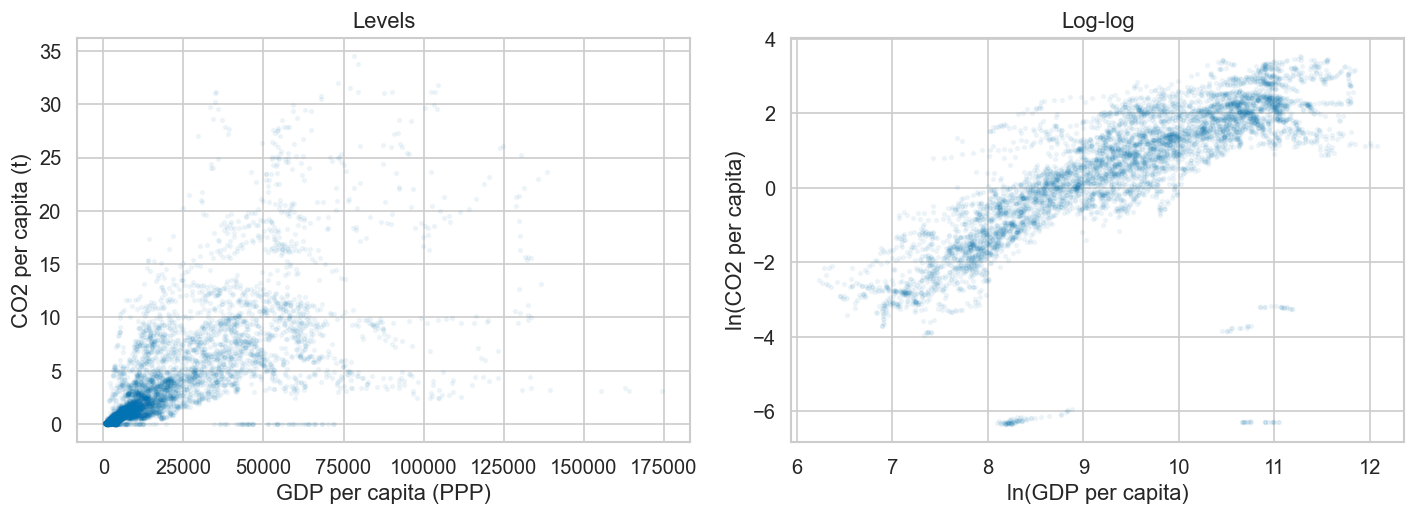

The log-log relationship is approximately linear, supporting a log-log specification.
Interpretation: coefficients represent elasticities (% change in CO2 per % change in GDP).


In [11]:
# Log transformations (replace non-positive values with NaN before logging)
panel["ln_gdp_pc"] = np.log(panel["gdp_pc"].where(panel["gdp_pc"] > 0))
panel["ln_co2_pc"] = np.log(panel["co2_pc"].where(panel["co2_pc"] > 0))

n_zero = (panel["co2_pc"] == 0).sum()
n_inf = np.isinf(panel["ln_co2_pc"]).sum()
print(f"Obs with zero CO2 per capita (dropped from log models): {n_zero}")

# Visualize: levels vs logs
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(panel["gdp_pc"], panel["co2_pc"], alpha=0.05, s=5)
axes[0].set(xlabel="GDP per capita (PPP)", ylabel="CO2 per capita (t)",
            title="Levels")

axes[1].scatter(panel["ln_gdp_pc"], panel["ln_co2_pc"], alpha=0.05, s=5)
axes[1].set(xlabel="ln(GDP per capita)", ylabel="ln(CO2 per capita)",
            title="Log-log")

plt.tight_layout()
plt.show()

print("The log-log relationship is approximately linear, supporting a log-log specification.")
print("Interpretation: coefficients represent elasticities (% change in CO2 per % change in GDP).")

## Models

In [12]:
# Prepare variables for first-difference models
panel = panel.sort_values(["iso3", "year"])

# First differences
panel["d_ln_co2_pc"] = panel.groupby("iso3")["ln_co2_pc"].diff()
panel["d_ln_gdp_pc"] = panel.groupby("iso3")["ln_gdp_pc"].diff()

# Lags of the first-differenced GDP
for lag in [1, 2, 3, 4, 5, 6]:
    panel[f"d_ln_gdp_pc_L{lag}"] = panel.groupby("iso3")["d_ln_gdp_pc"].shift(lag)

# Time trend (centered at first year for interpretability)
panel["trend"] = panel["year"] - panel["year"].min()

print("Variables prepared for modeling.")
print(f"Observations with complete ln values: {panel[['ln_gdp_pc','ln_co2_pc']].dropna().shape[0]}")
print(f"Observations with complete first-diff: {panel[['d_ln_gdp_pc','d_ln_co2_pc']].dropna().shape[0]}")

Variables prepared for modeling.
Observations with complete ln values: 6065
Observations with complete first-diff: 5879


In [13]:
# Model 1: Cross-section OLS for 2005
cs_2005 = panel[panel["year"] == 2005].dropna(subset=["ln_co2_pc", "ln_gdp_pc"])
m1 = smf.ols("ln_co2_pc ~ ln_gdp_pc", data=cs_2005).fit(cov_type="HC1")

In [14]:
# Model 2: Cross-section OLS for last year
cs_last = panel[panel["year"] == last_year].dropna(subset=["ln_co2_pc", "ln_gdp_pc"])
m2 = smf.ols("ln_co2_pc ~ ln_gdp_pc", data=cs_last).fit(cov_type="HC1")

In [15]:
# Model 3: First difference, time trend, no lags
fd_data = panel.dropna(subset=["d_ln_co2_pc", "d_ln_gdp_pc"])
m3 = smf.ols("d_ln_co2_pc ~ d_ln_gdp_pc + trend", data=fd_data).fit(
    cov_type="cluster", cov_kwds={"groups": fd_data["iso3"]})

In [16]:
# Model 4: First difference, time trend, 2-year lags
fd2_cols = ["d_ln_co2_pc", "d_ln_gdp_pc", "d_ln_gdp_pc_L1", "d_ln_gdp_pc_L2", "trend"]
fd2_data = panel.dropna(subset=fd2_cols)
m4 = smf.ols("d_ln_co2_pc ~ d_ln_gdp_pc + d_ln_gdp_pc_L1 + d_ln_gdp_pc_L2 + trend",
             data=fd2_data).fit(cov_type="cluster", cov_kwds={"groups": fd2_data["iso3"]})

In [17]:
# Model 5: First difference, time trend, 6-year lags
fd6_cols = ["d_ln_co2_pc", "d_ln_gdp_pc"] + [f"d_ln_gdp_pc_L{i}" for i in range(1, 7)] + ["trend"]
fd6_data = panel.dropna(subset=fd6_cols)
m5 = smf.ols(
    "d_ln_co2_pc ~ d_ln_gdp_pc + d_ln_gdp_pc_L1 + d_ln_gdp_pc_L2 + "
    "d_ln_gdp_pc_L3 + d_ln_gdp_pc_L4 + d_ln_gdp_pc_L5 + d_ln_gdp_pc_L6 + trend",
    data=fd6_data,
).fit(cov_type="cluster", cov_kwds={"groups": fd6_data["iso3"]})

# Joint F-test: are all 6 lags jointly significant?
lag_vars = [f"d_ln_gdp_pc_L{i}" for i in range(1, 7)]
hypothesis = ", ".join([f"{v} = 0" for v in lag_vars])
f_test = m5.f_test(hypothesis)
fval = float(np.squeeze(f_test.fvalue))
pval = float(np.squeeze(f_test.pvalue))
print(f"Joint F-test for lags L1-L6: F={fval:.3f}, p={pval:.4f}")

Joint F-test for lags L1-L6: F=1.228, p=0.2939


In [18]:
# Model 6: Fixed effects with country and year FEs (clustered SEs by country)
panel_fe = panel.dropna(subset=["ln_co2_pc", "ln_gdp_pc"]).set_index(["iso3", "year"])
m6 = PanelOLS.from_formula("ln_co2_pc ~ ln_gdp_pc + EntityEffects + TimeEffects",
                           data=panel_fe).fit(cov_type="clustered", cluster_entity=True)

In [19]:
# Combined regression table for all 6 models
def _fmt(coef, se, pval):
    """Format coefficient with stars and SE in parentheses."""
    stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
    return f"{coef:.3f}{stars}", f"({se:.3f})"

def _extract(model, var, is_panel=False):
    """Extract coef/se/pval from statsmodels or linearmodels result."""
    if is_panel:
        if var in model.params.index:
            return _fmt(model.params[var], model.std_errors[var], model.pvalues[var])
        return "", ""
    else:
        if var in model.params.index:
            return _fmt(model.params[var], model.bse[var], model.pvalues[var])
        return "", ""

models = [m1, m2, m3, m4, m5, m6]
is_panel = [False, False, False, False, False, True]
col_names = [f"(1) OLS\n2005", f"(2) OLS\n{last_year}", "(3) FD", "(4) FD\n+2 lags", "(5) FD\n+6 lags", "(6) TWFE"]

covariates = [
    ("ln(GDP pc)", "ln_gdp_pc"),
    ("d ln(GDP pc)", "d_ln_gdp_pc"),
    ("d ln(GDP pc), L1", "d_ln_gdp_pc_L1"),
    ("d ln(GDP pc), L2", "d_ln_gdp_pc_L2"),
    ("d ln(GDP pc), L3", "d_ln_gdp_pc_L3"),
    ("d ln(GDP pc), L4", "d_ln_gdp_pc_L4"),
    ("d ln(GDP pc), L5", "d_ln_gdp_pc_L5"),
    ("d ln(GDP pc), L6", "d_ln_gdp_pc_L6"),
    ("Time trend", "trend"),
    ("Constant", "Intercept"),
]

rows = []
for label, var in covariates:
    coef_row = {"": label}
    se_row = {"": ""}
    has_any = False
    for i, (mod, pan) in enumerate(zip(models, is_panel)):
        c, s = _extract(mod, var, pan)
        coef_row[col_names[i]] = c
        se_row[col_names[i]] = s
        if c:
            has_any = True
    if has_any:
        rows.append(coef_row)
        rows.append(se_row)

# Add footer stats
sep = {"": ""}
for cn in col_names:
    sep[cn] = ""
rows.append(sep)

# Country FE
fe_row = {"": "Country FE"}
for i, cn in enumerate(col_names):
    fe_row[cn] = "Yes" if i == 5 else "No"
rows.append(fe_row)

# Year FE
fe_row2 = {"": "Year FE"}
for i, cn in enumerate(col_names):
    fe_row2[cn] = "Yes" if i == 5 else "No"
rows.append(fe_row2)

# SE type
se_type_row = {"": "SE type"}
se_types = ["Robust", "Robust", "Clustered", "Clustered", "Clustered", "Clustered"]
for i, cn in enumerate(col_names):
    se_type_row[cn] = se_types[i]
rows.append(se_type_row)

# Observations
obs_row = {"": "Observations"}
for i, (mod, pan) in enumerate(zip(models, is_panel)):
    obs_row[col_names[i]] = f"{int(mod.nobs):,}"
rows.append(obs_row)

# R-squared
r2_row = {"": "R-squared"}
for i, (mod, pan) in enumerate(zip(models, is_panel)):
    r2 = mod.rsquared_within if pan else mod.rsquared
    r2_row[col_names[i]] = f"{r2:.3f}"
rows.append(r2_row)

table = pd.DataFrame(rows).set_index("")

DualTable(table, caption="CO2 per capita and GDP per capita (log-log)")

,(1) OLS 2005,(2) OLS 2024,(3) FD,(4) FD +2 lags,(5) FD +6 lags,(6) TWFE
,,,,,,
ln(GDP pc),1.214***,1.058***,,,,0.599***
,(0.076),(0.065),,,,(0.080)
d ln(GDP pc),,,0.473***,0.453***,0.482***,
,,,(0.057),(0.062),(0.069),
"d ln(GDP pc), L1",,,,-0.044,-0.034,
,,,,(0.046),(0.049),
"d ln(GDP pc), L2",,,,0.041,-0.009,
,,,,(0.028),(0.035),
"d ln(GDP pc), L3",,,,,0.072*,


### Interpretation notes

- Cross-section elasticity ~1.1-1.2, drops to ~0.47 (FD) and ~0.60 (TWFE) within-country
- FD equivalent to country FEs; time trend allows quadratic in levels
- Low FD R-squared (~0.04) expected for year-to-year changes
- Lags jointly insignificant (F=1.23, p=0.29), effect is contemporaneous
- TWFE higher than FD because it captures medium-run adjustments
- Caveats: reverse causality, monotonicity assumption

See report.md for full discussion.

In [20]:
# Subsample analysis: High income vs non-high income
hi = panel[panel["income_group"] == "High income"]
non_hi = panel[panel["income_group"] != "High income"]

# TWFE for each subsample
hi_fe = hi.dropna(subset=["ln_co2_pc", "ln_gdp_pc"]).set_index(["iso3", "year"])
m6_hi = PanelOLS.from_formula("ln_co2_pc ~ ln_gdp_pc + EntityEffects + TimeEffects",
                               data=hi_fe).fit(cov_type="clustered", cluster_entity=True)

non_hi_fe = non_hi.dropna(subset=["ln_co2_pc", "ln_gdp_pc"]).set_index(["iso3", "year"])
m6_non = PanelOLS.from_formula("ln_co2_pc ~ ln_gdp_pc + EntityEffects + TimeEffects",
                                data=non_hi_fe).fit(cov_type="clustered", cluster_entity=True)

# Comparison table
sub_rows = []
for label, var in [("ln(GDP pc)", "ln_gdp_pc")]:
    c_all, s_all = _fmt(m6.params[var], m6.std_errors[var], m6.pvalues[var])
    c_hi, s_hi = _fmt(m6_hi.params[var], m6_hi.std_errors[var], m6_hi.pvalues[var])
    c_non, s_non = _fmt(m6_non.params[var], m6_non.std_errors[var], m6_non.pvalues[var])
    sub_rows.append({"": label, "All countries": c_all, "High income": c_hi, "Non-high income": c_non})
    sub_rows.append({"": "", "All countries": s_all, "High income": s_hi, "Non-high income": s_non})

sub_rows.append({"": "", "All countries": "", "High income": "", "Non-high income": ""})
sub_rows.append({"": "Country + Year FE", "All countries": "Yes", "High income": "Yes", "Non-high income": "Yes"})
sub_rows.append({"": "SE type", "All countries": "Clustered", "High income": "Clustered", "Non-high income": "Clustered"})
sub_rows.append({"": "Countries", "All countries": f"{int(m6.entity_info['total'])}", "High income": f"{int(m6_hi.entity_info['total'])}", "Non-high income": f"{int(m6_non.entity_info['total'])}"})
sub_rows.append({"": "Observations", "All countries": f"{int(m6.nobs):,}", "High income": f"{int(m6_hi.nobs):,}", "Non-high income": f"{int(m6_non.nobs):,}"})
sub_rows.append({"": "R-squared (within)", "All countries": f"{m6.rsquared_within:.3f}", "High income": f"{m6_hi.rsquared_within:.3f}", "Non-high income": f"{m6_non.rsquared_within:.3f}"})

sub_table = pd.DataFrame(sub_rows).set_index("")
DualTable(sub_table, caption="TWFE subsample analysis: High income vs non-high income")

,All countries,High income,Non-high income
,,,
ln(GDP pc),0.599***,0.363**,0.609***
,(0.080),(0.150),(0.093)
,,,
Country + Year FE,Yes,Yes,Yes
SE type,Clustered,Clustered,Clustered
Countries,186,67,119
Observations,"6,065","2,152","3,913"
R-squared (within),0.222,0.009,0.384


Subsample: high-income elasticity 0.36 (barely significant, R2w=0.009) vs non-high-income 0.61 (R2w=0.38). Decoupling confirmed for rich countries.

## Confounder: Urbanization

In [21]:
# Download urbanization data (% urban population) from World Bank API
urb_raw = wb.data.DataFrame("SP.URB.TOTL.IN.ZS", time=range(1992, 2025), labels=False)
urb_long = urb_raw.reset_index().melt(id_vars="economy", var_name="yr", value_name="urban_pct")
urb_long["year"] = urb_long["yr"].str.replace("YR", "").astype(int)
urb_long = urb_long.rename(columns={"economy": "iso3"}).drop(columns="yr")

# Merge into panel
panel = panel.merge(urb_long, on=["iso3", "year"], how="left")
panel["ln_urban_pct"] = np.log(panel["urban_pct"].where(panel["urban_pct"] > 0))
panel["d_ln_urban_pct"] = panel.groupby("iso3")["ln_urban_pct"].diff()

print(f"Urbanization merged. Missing: {panel['urban_pct'].isna().sum()} obs ({panel['urban_pct'].isna().mean():.1%})")

# Model 1c: Cross-section OLS 2005 + urbanization (robust SEs)
cs_2005c = panel[panel["year"] == 2005].dropna(subset=["ln_co2_pc", "ln_gdp_pc", "ln_urban_pct"])
m1c = smf.ols("ln_co2_pc ~ ln_gdp_pc + ln_urban_pct", data=cs_2005c).fit(cov_type="HC1")

# Model 4c: FD + 2 lags + urbanization (clustered SEs)
fd2c_cols = ["d_ln_co2_pc", "d_ln_gdp_pc", "d_ln_gdp_pc_L1", "d_ln_gdp_pc_L2", "trend", "d_ln_urban_pct"]
fd2c_data = panel.dropna(subset=fd2c_cols)
m4c = smf.ols("d_ln_co2_pc ~ d_ln_gdp_pc + d_ln_gdp_pc_L1 + d_ln_gdp_pc_L2 + trend + d_ln_urban_pct",
              data=fd2c_data).fit(cov_type="cluster", cov_kwds={"groups": fd2c_data["iso3"]})

# Model 6c: TWFE + urbanization (clustered SEs)
panel_fe_c = panel.dropna(subset=["ln_co2_pc", "ln_gdp_pc", "ln_urban_pct"]).set_index(["iso3", "year"])
m6c = PanelOLS.from_formula("ln_co2_pc ~ ln_gdp_pc + ln_urban_pct + EntityEffects + TimeEffects",
                            data=panel_fe_c).fit(cov_type="clustered", cluster_entity=True)

Urbanization merged. Missing: 0 obs (0.0%)


In [22]:
# Confounder comparison table: original vs with urbanization
conf_models = [m1, m1c, m4, m4c, m6, m6c]
conf_is_panel = [False, False, False, False, True, True]
conf_cols = ["(1) OLS\n2005", "(1c) +Urban", "(4) FD\n+2 lags", "(4c) +Urban", "(6) TWFE", "(6c) +Urban"]

conf_covariates = [
    ("ln(GDP pc)", "ln_gdp_pc"),
    ("ln(Urban %)", "ln_urban_pct"),
    ("d ln(GDP pc)", "d_ln_gdp_pc"),
    ("d ln(GDP pc), L1", "d_ln_gdp_pc_L1"),
    ("d ln(GDP pc), L2", "d_ln_gdp_pc_L2"),
    ("d ln(Urban %)", "d_ln_urban_pct"),
    ("Time trend", "trend"),
    ("Constant", "Intercept"),
]

rows = []
for label, var in conf_covariates:
    coef_row = {"": label}
    se_row = {"": ""}
    has_any = False
    for i, (mod, pan) in enumerate(zip(conf_models, conf_is_panel)):
        c, s = _extract(mod, var, pan)
        coef_row[conf_cols[i]] = c
        se_row[conf_cols[i]] = s
        if c:
            has_any = True
    if has_any:
        rows.append(coef_row)
        rows.append(se_row)

sep = {"": ""}
for cn in conf_cols:
    sep[cn] = ""
rows.append(sep)

fe_row = {"": "Country FE"}
for i, cn in enumerate(conf_cols):
    fe_row[cn] = "Yes" if conf_is_panel[i] else "No"
rows.append(fe_row)

fe_row2 = {"": "Year FE"}
for i, cn in enumerate(conf_cols):
    fe_row2[cn] = "Yes" if conf_is_panel[i] else "No"
rows.append(fe_row2)

se_type_row = {"": "SE type"}
conf_se_types = ["Robust", "Robust", "Clustered", "Clustered", "Clustered", "Clustered"]
for i, cn in enumerate(conf_cols):
    se_type_row[cn] = conf_se_types[i]
rows.append(se_type_row)

obs_row = {"": "Observations"}
for i, (mod, pan) in enumerate(zip(conf_models, conf_is_panel)):
    obs_row[conf_cols[i]] = f"{int(mod.nobs):,}"
rows.append(obs_row)

r2_row = {"": "R-squared"}
for i, (mod, pan) in enumerate(zip(conf_models, conf_is_panel)):
    r2 = mod.rsquared_within if pan else mod.rsquared
    r2_row[conf_cols[i]] = f"{r2:.3f}"
rows.append(r2_row)

conf_table = pd.DataFrame(rows).set_index("")
DualTable(conf_table, caption="Adding urbanization as a confounder")

,(1) OLS 2005,(1c) +Urban,(4) FD +2 lags,(4c) +Urban,(6) TWFE,(6c) +Urban
,,,,,,
ln(GDP pc),1.214***,1.099***,,,0.599***,0.539***
,(0.076),(0.119),,,(0.080),(0.072)
ln(Urban %),,0.358,,,,0.982***
,,(0.304),,,,(0.198)
d ln(GDP pc),,,0.453***,0.449***,,
,,,(0.062),(0.062),,
"d ln(GDP pc), L1",,,-0.044,-0.045,,
,,,(0.046),(0.046),,
"d ln(GDP pc), L2",,,0.041,0.037,,


### Confounder notes

- Cross-section: urbanization insignificant, GDP drops slightly (1.21 to 1.10)
- FD: urbanization growth significant (0.59), GDP unchanged
- TWFE: urbanization near-unit elasticity (0.98), GDP drops 0.60 to 0.54, R2 jumps
- TWFE > FD urbanization coefficient because slow-moving infrastructure channels
- Causal ambiguity: confounder vs mediator (GDP -> urbanization -> CO2)
- 0.60 = total effect, 0.54 = direct effect; difference = urbanization channel

See report.md for full discussion.

## Summary

Best estimate of within-country GDP-CO2 elasticity: 0.54-0.60. Below 1 (emissions grow slower than GDP) but still positive (growth increases emissions). High-income countries nearly decoupled (0.36); developing countries still strongly coupled (0.61). See report.md for full summary.

In [23]:
# Export all figures and tables to output/
import os
outdir = "output"
os.makedirs(outdir, exist_ok=True)

# --- Figures ---

fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4))
axes1[0].hist(panel["gdp_pc"].dropna(), bins=50, edgecolor="white")
axes1[0].set(xlabel="GDP per capita (PPP $)", ylabel="Count", title="GDP per capita distribution")
axes1[1].hist(panel["co2_pc"].dropna(), bins=50, edgecolor="white")
axes1[1].set(xlabel="CO2 per capita (tonnes)", ylabel="Count", title="CO2 per capita distribution")
fig1.tight_layout()
fig1.savefig(f"{outdir}/fig1_distributions.png", dpi=200, bbox_inches="tight")
plt.close(fig1)

grouped = panel.groupby(["year", "income_group"])[["gdp_pc", "co2_pc"]].mean().reset_index()
order = ["High income", "Upper middle", "Lower middle", "Low income"]
colors = dict(zip(order, sns.color_palette("colorblind", 4)))
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
for grp in order:
    sub = grouped[grouped["income_group"] == grp]
    axes2[0].plot(sub["year"], sub["gdp_pc"] / 1000, label=grp, color=colors[grp], linewidth=2)
    axes2[1].plot(sub["year"], sub["co2_pc"], label=grp, color=colors[grp], linewidth=2)
axes2[0].set(xlabel="Year", ylabel="Mean GDP per capita (thousand PPP $)", title="GDP per capita by income group")
axes2[0].legend(loc="upper left")
axes2[1].set(xlabel="Year", ylabel="Mean CO2 per capita (tonnes)", title="CO2 per capita by income group")
axes2[1].legend(loc="upper left")
axes2[1].annotate("Decoupling: GDP rises,\nCO2 falls after ~2007",
                  xy=(2007, 9.0), xytext=(2012, 6.5),
                  arrowprops=dict(arrowstyle="->", color="gray"), fontsize=9, color="gray")
fig2.tight_layout()
fig2.savefig(f"{outdir}/fig2_time_series.png", dpi=200, bbox_inches="tight")
plt.close(fig2)

fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4.5))
axes3[0].scatter(panel["gdp_pc"], panel["co2_pc"], alpha=0.05, s=5)
axes3[0].set(xlabel="GDP per capita (PPP)", ylabel="CO2 per capita (t)", title="Levels")
axes3[1].scatter(panel["ln_gdp_pc"], panel["ln_co2_pc"], alpha=0.05, s=5)
axes3[1].set(xlabel="ln(GDP per capita)", ylabel="ln(CO2 per capita)", title="Log-log")
fig3.tight_layout()
fig3.savefig(f"{outdir}/fig3_functional_form.png", dpi=200, bbox_inches="tight")
plt.close(fig3)

# --- Tables (.tex only) ---

def save_tex(df, path, caption=None):
    df = df.copy()
    df.columns = [str(c).replace("\n", " ") for c in df.columns]
    tex = df.to_latex(column_format="l" + "r" * len(df.columns), escape=True)
    with open(path, "w") as f:
        f.write("\\begin{table}[h]\n\\centering\n")
        if caption:
            f.write(f"\\caption{{{caption}}}\n")
        f.write(tex)
        f.write("\\end{table}\n")

desc = panel[["gdp_pc", "co2_total_mt", "co2_pc"]].describe()
desc.columns = ["GDP per capita (PPP)", "CO2 total (Mt)", "CO2 per capita (t)"]
desc["GDP per capita (PPP)"] = desc["GDP per capita (PPP)"].map(lambda x: f"{x:,.1f}")
desc["CO2 total (Mt)"] = desc["CO2 total (Mt)"].map(lambda x: f"{x:,.3f}")
desc["CO2 per capita (t)"] = desc["CO2 per capita (t)"].map(lambda x: f"{x:,.3f}")
save_tex(desc, f"{outdir}/tab1_descriptive.tex", "Descriptive statistics")

n_countries = panel["iso3"].nunique()
yr_min, yr_max = panel["year"].min(), panel["year"].max()
cov = pd.DataFrame({
    "Variable": ["GDP per capita", "CO2 total", "Population", "CO2 per capita"],
    "Non-missing": [f"{panel['gdp_pc'].notna().sum():,}", f"{panel['co2_total_mt'].notna().sum():,}",
                    f"{panel['population'].notna().sum():,}", f"{panel['co2_pc'].notna().sum():,}"],
    "Missing": [f"{panel['gdp_pc'].isna().sum():,}", f"{panel['co2_total_mt'].isna().sum():,}",
                f"{panel['population'].isna().sum():,}", f"{panel['co2_pc'].isna().sum():,}"],
    "Missing pct": [f"{panel['gdp_pc'].isna().mean():.1%}", f"{panel['co2_total_mt'].isna().mean():.1%}",
                    f"{panel['population'].isna().mean():.1%}", f"{panel['co2_pc'].isna().mean():.1%}"],
}).set_index("Variable")
save_tex(cov, f"{outdir}/tab2_coverage.tex", f"Data availability ({n_countries} countries, {yr_min}-{yr_max})")

reg = table.copy()
save_tex(reg, f"{outdir}/tab3_regressions.tex", "CO2 per capita and GDP per capita (log-log)")

save_tex(sub_table, f"{outdir}/tab4_subsample.tex", "TWFE subsample analysis")

conf = conf_table.copy()
save_tex(conf, f"{outdir}/tab5_confounder.tex", "Adding urbanization as a confounder")

print("Exported to output/:")
for f in sorted(os.listdir(outdir)):
    print(f"  {f}")

Exported to output/:
  fig1_distributions.png
  fig2_time_series.png
  fig3_functional_form.png
  tab1_descriptive.tex
  tab2_coverage.tex
  tab3_regressions.tex
  tab4_subsample.tex
  tab5_confounder.tex
